# I. Tải dữ liệu

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
from IPython.display import display
warnings.filterwarnings('ignore')
from sklearn.preprocessing import StandardScaler
from mlxtend.preprocessing import TransactionEncoder

# Cấu hình hiển thị
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
df = pd.read_excel('Online Retail.xlsx')

# II. Khám phá dữ liệu

## 1. Đọc dữ liệu

In [3]:
print("\n- Kích thước của bộ dữ liệu:")
print(f" Số dòng: {df.shape[0]}")
print(f" Số cột: {df.shape[1]}")


- Kích thước của bộ dữ liệu:
 Số dòng: 541909
 Số cột: 8


In [4]:
print("\n 5 dòng đầu tiên:")
display(df.head())
print("\n 5 dòng cuối cùng:")
display(df.tail())


 5 dòng đầu tiên:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom



 5 dòng cuối cùng:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


In [5]:
print(" Thông tin kiểu dữ liệu và bộ nhớ:\n")
print(df.info())

 Thông tin kiểu dữ liệu và bộ nhớ:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB
None


In [6]:
print("\n Danh sách các cột:")
print(df.columns.tolist())


 Danh sách các cột:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']


In [7]:
print(" Kiểu dữ liệu từng cột:\n")
print(df.dtypes)

 Kiểu dữ liệu từng cột:

InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object


## 2. Thống kê mô tả ban đầu

In [8]:
print("\n Thống kê mô tả cho các biến số (Numerical):")
display(df.describe())

print("\n Thống kê mô tả các biến phân loại (Categorical):")
display(df.describe(include=['object', 'category']))


 Thống kê mô tả cho các biến số (Numerical):


,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303



 Thống kê mô tả các biến phân loại (Categorical):


,InvoiceNo,StockCode,Description,Country
count,541909,541909,540455,541909
unique,25900,4070,4223,38
top,573585,85123A,WHITE HANGING HEART T-LIGHT HOLDER,United Kingdom
freq,1114,2313,2369,495478


In [9]:
print("\nKiểm tra tính nhất quán của các biến số: ")
print(" - Số lượng ngày lập hoá đơn duy nhất ",df['InvoiceDate'].nunique())
print(" - Số lượng khách hàng duy nhất ",df['CustomerID'].nunique())
print(" - Số lượng đơn giá duy nhất ",df['UnitPrice'].nunique(),"\n")


Kiểm tra tính nhất quán của các biến số: 
 - Số lượng ngày lập hoá đơn duy nhất  23260
 - Số lượng khách hàng duy nhất  4372
 - Số lượng đơn giá duy nhất  1630 



In [10]:
return_quantity = df[df['Quantity'] < 0]
print(f"Tổng số dòng có Quantity âm: {len(return_quantity)}")
print("Các dòng đầu có Quantity âm:")
display(return_quantity.head(10))

negative_unitprice = df[df['UnitPrice'] < 0]
print(f"\nTổng số dòng có UnitPrice âm: {len(negative_unitprice)}")
print("Các dòng đầu có UnitPrice âm:")
display(negative_unitprice.head(10))


Tổng số dòng có Quantity âm: 10624
Các dòng đầu có Quantity âm:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
238,C536391,21980,PACK OF 12 RED RETROSPOT TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
239,C536391,21484,CHICK GREY HOT WATER BOTTLE,-12,2010-12-01 10:24:00,3.45,17548.0,United Kingdom
240,C536391,22557,PLASTERS IN TIN VINTAGE PAISLEY,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
241,C536391,22553,PLASTERS IN TIN SKULLS,-24,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
939,C536506,22960,JAM MAKING SET WITH JARS,-6,2010-12-01 12:38:00,4.25,17897.0,United Kingdom



Tổng số dòng có UnitPrice âm: 2
Các dòng đầu có UnitPrice âm:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
299983,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,NaN,United Kingdom
299984,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,NaN,United Kingdom


In [11]:
# Biến số (numerical)
numerical_dt = ['Quantity', 'UnitPrice', 'CustomerID']

# Biến phân loại (categorical)
categorical_dt = ['InvoiceNo', 'StockCode', 'Description', 'Country']

# Biến thời gian (datetime)
datetime_dt = ['InvoiceDate']

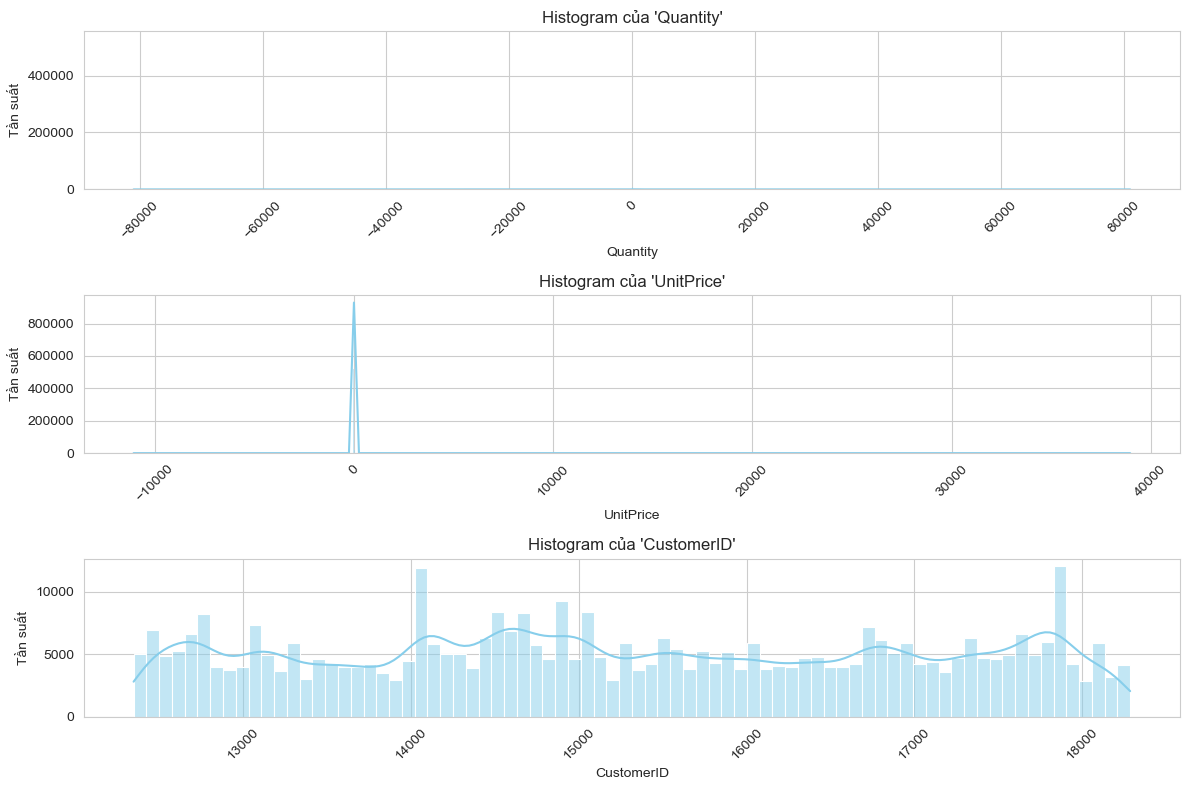

In [12]:
fig, axes = plt.subplots(3, 1, figsize=(12, 8))
for i, col in enumerate(numerical_dt):
    ax = axes[i]
    sns.histplot(data=df, x=col, kde=True, ax=ax, color='skyblue')
    ax.set_title(f"Histogram của '{col}'", fontsize=12)
    ax.set_xlabel(col)
    ax.set_ylabel("Tần suất")
    ax.tick_params(axis='x', labelrotation=45)
    ax.grid(True)

plt.tight_layout()
plt.show() 

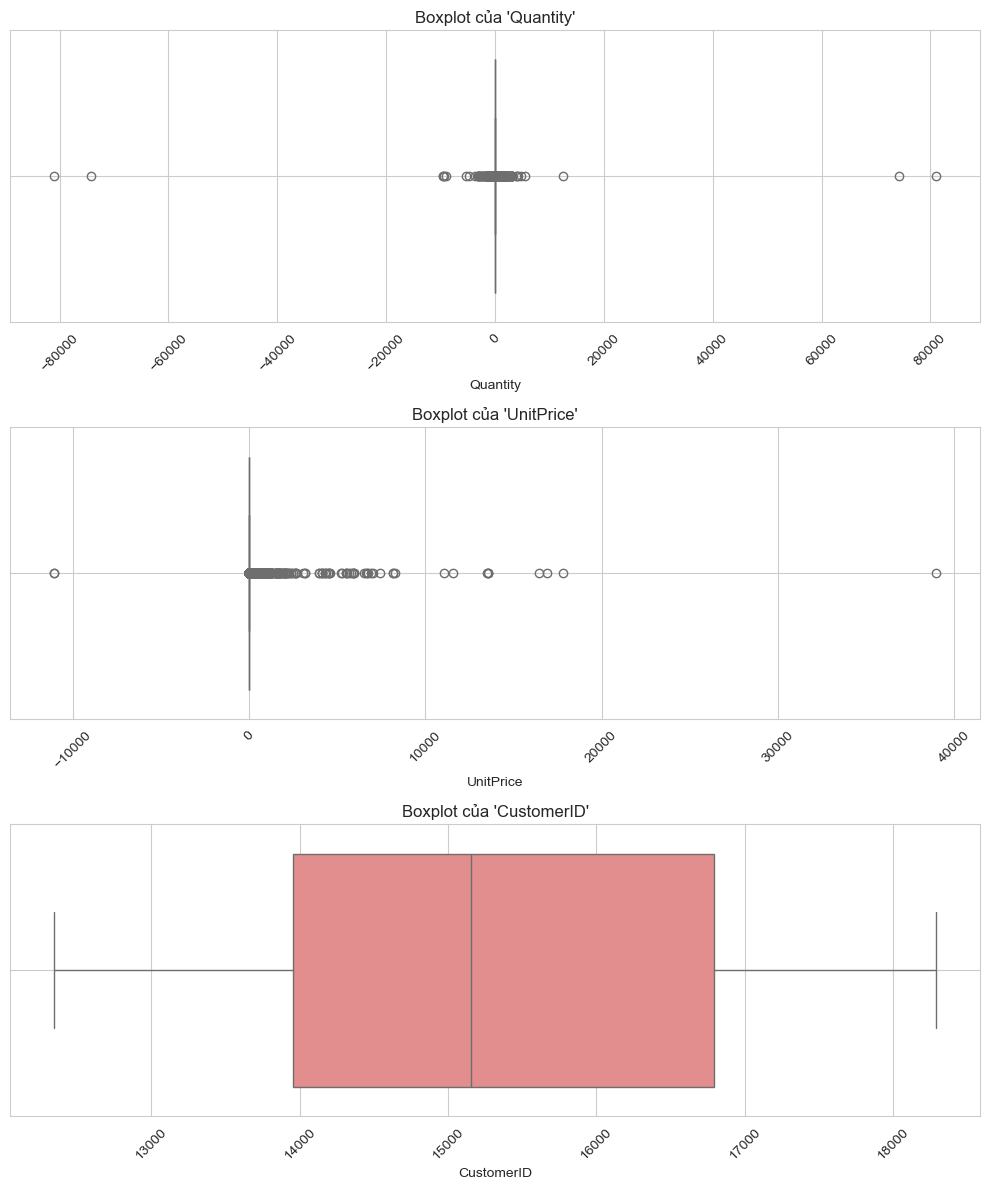

In [13]:
fig, axes = plt.subplots(3, 1, figsize=(10, 12))

for i, col in enumerate(['Quantity', 'UnitPrice', 'CustomerID']):
    ax = axes[i]
    sns.boxplot(data=df, x=col, ax=ax, color='lightcoral')
    ax.set_title(f"Boxplot của '{col}'", fontsize=12)
    ax.set_xlabel(col)
    ax.tick_params(axis='x', labelrotation=45)
    ax.grid(True)

plt.tight_layout()
plt.show()

## 3. Kiểm tra chất lượng của dữ liệu

In [14]:
print(" Kiểm tra giá trị bị thiếu (Null/NaN)")
missing_stats = pd.DataFrame({
    'Số lượng thiếu': df.isnull().sum(),
    'Tỷ lệ thiếu (%)': (df.isnull().sum() / len(df)) * 100
})
display(missing_stats[missing_stats['Số lượng thiếu'] > 0])

 Kiểm tra giá trị bị thiếu (Null/NaN)


,Số lượng thiếu,Tỷ lệ thiếu (%)
Description,1454,0.268311
CustomerID,135080,24.926694


In [15]:
print("\nKiểm tra dòng trùng lặp hoàn toàn:")
duplicate_count = df.duplicated().sum()
print(f" - Số dòng trùng lặp: {duplicate_count}")
print(f" - Tỷ lệ trùng lặp: {(duplicate_count/len(df)*100):.2f}%")

duplicates = df[df.duplicated()]
if not duplicates.empty:
    print("\nCác dòng bị trùng:")
    display(duplicates.head(10))


Kiểm tra dòng trùng lặp hoàn toàn:
 - Số dòng trùng lặp: 5268
 - Tỷ lệ trùng lặp: 0.97%

Các dòng bị trùng:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
555,536412,22327,ROUND SNACK BOXES SET OF 4 SKULLS,1,2010-12-01 11:49:00,2.95,17920.0,United Kingdom
587,536412,22273,FELTCRAFT DOLL MOLLY,1,2010-12-01 11:49:00,2.95,17920.0,United Kingdom
589,536412,22749,FELTCRAFT PRINCESS CHARLOTTE DOLL,1,2010-12-01 11:49:00,3.75,17920.0,United Kingdom
594,536412,22141,CHRISTMAS CRAFT TREE TOP ANGEL,1,2010-12-01 11:49:00,2.10,17920.0,United Kingdom
598,536412,21448,12 DAISY PEGS IN WOOD BOX,1,2010-12-01 11:49:00,1.65,17920.0,United Kingdom
600,536412,22569,FELTCRAFT CUSHION BUTTERFLY,2,2010-12-01 11:49:00,3.75,17920.0,United Kingdom


In [16]:
print("\nKiểm tra giá trị bất thường trong biến số lượng(Quantity):")
print(f" - Min Quantity: {df['Quantity'].min()}")
print(f" - Max Quantity: {df['Quantity'].max()}")
print(f" - Số giao dịch có Quantity <= 0: {(df['Quantity'] <= 0).sum()}")


Kiểm tra giá trị bất thường trong biến số lượng(Quantity):
 - Min Quantity: -80995
 - Max Quantity: 80995
 - Số giao dịch có Quantity <= 0: 10624


In [17]:
print("\nKiểm tra giá trị bất thường trong biến đơn giá(UnitPrice):")
print(f" - Min UnitPrice: {df['UnitPrice'].min()}")
print(f" - Max UnitPrice: {df['UnitPrice'].max()}")
print(f" - Số giao dịch có UnitPrice <= 0: {(df['UnitPrice'] <= 0).sum()}")


Kiểm tra giá trị bất thường trong biến đơn giá(UnitPrice):
 - Min UnitPrice: -11062.06
 - Max UnitPrice: 38970.0
 - Số giao dịch có UnitPrice <= 0: 2517


In [18]:
print("\nPhân tích Số hoá đơn(InvoiceNo) bắt đầu bằng 'C' (Cancellation):")
df['IsCancelled'] = df['InvoiceNo'].astype(str).str.startswith('C')
cancelled_count = df['IsCancelled'].sum()
print(f" - Số giao dịch hủy: {cancelled_count}")
print(f" - Tỷ lệ giao dịch hủy: {(cancelled_count/len(df)*100):.2f}%")


Phân tích Số hoá đơn(InvoiceNo) bắt đầu bằng 'C' (Cancellation):
 - Số giao dịch hủy: 9288
 - Tỷ lệ giao dịch hủy: 1.71%
